# Logistic Regression

**Logistic regression** is the perceptron with one part swapped: the hard **sign** activation becomes a smooth **sigmoid**, so instead of committing to a class the neuron outputs a *probability* between 0 and 1. The cost changes from counting misclassifications to **binary cross-entropy**, but the update rule works out to the same $(\hat{y} - y)x$ as before. Because it outputs probabilities, it handles overlapping data that the perceptron couldn't separate.

**Net input:** $z = \mathbf{w} \cdot \mathbf{x} + b$

**Activation (sigmoid):** $\hat{y} = \sigma(z) = \dfrac{1}{1 + e^{-z}}$, squashes the net input into a probability in $(0, 1)$.

**Cost (binary cross-entropy):** $C(\mathbf{w}, b) = -\dfrac{1}{N}\sum_{i=1}^{N}\big[\,y^{(i)}\log\hat{y}^{(i)} + (1-y^{(i)})\log(1-\hat{y}^{(i)})\,\big]$

**Update rule:** $w_i \leftarrow w_i - \eta(\hat{y} - y)x_i,\quad b \leftarrow b - \eta(\hat{y} - y)$

| Symbol | Meaning |
|--------|---------|
| $\mathbf{x}$ | input feature — here, a tumor's *worst concave points* |
| $\mathbf{w}$ | learned weight(s) |
| $b$ | bias |
| $z$ | net input, $\mathbf{w}\cdot\mathbf{x} + b$ |
| $\sigma(z)$ | sigmoid activation |
| $\hat{y}$ | predicted **probability** that the tumor is malignant |
| $y$ | true label (1 = malignant, 0 = benign) |
| $\eta$ | learning rate |
| $N$ | number of training examples |

**This notebook** uses the [breast cancer dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset) of 569 tumors, predicting the **probability a tumor is malignant** from a single feature, *worst concave points*. This feature counts how many spots on a cell nucleus boundary curve **inward** (like dents or notches); the "worst" means the average over the three most extreme nuclei in the image, capturing the most irregular cells in the sample. Malignant tumors tend to have jagged, misshapen nuclei, so this count is a strong cancer signal. Unlike the perfectly separable penguins, this data overlaps in the middle, which is exactly where a probability is more important than a hard guess.

## Imports and Setup

NumPy for the math, matplotlib and seaborn for plotting, and the breast cancer dataset plus a few helpers from scikit-learn.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

sns.set_theme()  # nicer default plot styling

# Load the breast cancer data from the shared Datasets folder.
# The "../" steps out of this algorithm folder and into Supervised-Learning/Datasets.
# df = pd.read_csv("../Datasets/breast_cancer.csv")

# If you don't have the CSV locally, you can load it straight from scikit-learn instead:
from sklearn.datasets import load_breast_cancer
raw = load_breast_cancer(as_frame=True)
df = raw.frame

# Preview the first 5 rows to confirm the data loaded correctly and see the column names.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## The Data

Each row is a breast mass that was biopsied and imaged; the features are measurements of the cell nuclei (size, shape, texture). The diagnosis is binary: **malignant** or **benign**. We'll use one strong feature, **worst concave points** (how sharply the nucleus boundary dips inward for the most extreme nuclei), which rises clearly for malignant tumors.

### Encoding the labels

scikit-learn codes this dataset as **0 = malignant, 1 = benign**, which is backwards from how we'd read it. We remap so that **1 = malignant**, so the model's output reads naturally as "the probability the tumor is malignant.\"

In [3]:
# Remap: scikit-learn uses 0 = malignant, 1 = benign. Flip so 1 = malignant.
y = np.where(df["target"] == 0, 1, 0)

# Single feature: worst concave points (column needs to be a 2D matrix for the model).
X = df["worst concave points"].values.reshape(-1, 1)

print(f"Tumors: {len(y)}")
print(f"Malignant (1): {y.sum()}   Benign (0): {len(y) - y.sum()}")

Tumors: 569
Malignant (1): 212   Benign (0): 357


### Looking at the one feature

We plot each tumor at its feature value, with benign at 0 and malignant at 1. The two groups clearly shift apart, but they **overlap in the middle**, so no single cutoff separates them perfectly. That overlap is where a probability beats a hard label.

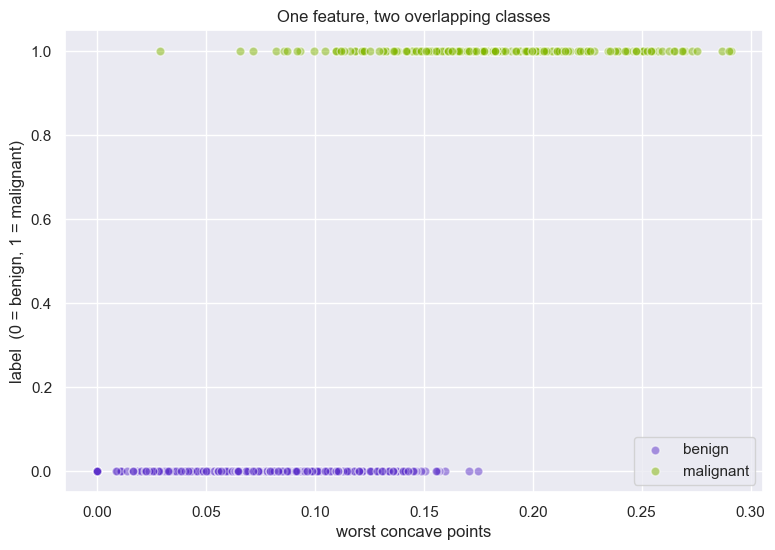

In [4]:
plt.figure(figsize=(9, 6))
plt.scatter(X[y == 0], np.zeros((y == 0).sum()), color="#5d32ca", alpha=0.5, edgecolors="white", s=40, label="benign")
plt.scatter(X[y == 1], np.ones((y == 1).sum()),  color="#82b600", alpha=0.5, edgecolors="white", s=40, label="malignant")
plt.xlabel("worst concave points")
plt.ylabel("label  (0 = benign, 1 = malignant)")
plt.title("One feature, two overlapping classes")
plt.legend()
plt.show()

### Preparing the data: split and standardize

Same two steps as the linear regression notebook: hold out 20% as a test set, and **standardize** the feature (mean 0, std 1) using the training set's statistics only. Standardizing keeps the sigmoid's input in a sensible range so stochastic gradient descent behaves efficiently.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

mean, standard_deviation = X_train.mean(), X_train.std()
X_train_s = (X_train - mean) / standard_deviation
X_test_s  = (X_test  - mean) / standard_deviation

print(f"Training tumors: {len(y_train)} | Test tumors: {len(y_test)}")

Training tumors: 455 | Test tumors: 114


## The Sigmoid and Cross-Entropy

### What changed from the perceptron

Two swaps, and that's it:

- **Activation:** the perceptron's hard `sign` (which jumps from -1 to +1) becomes the smooth **sigmoid** $\sigma(z) = \frac{1}{1+e^{-z}}$, which curves gently from 0 to 1. The output is now a probability instead of a class.

- **Cost:** counting misclassifications becomes **binary cross-entropy**, which rewards confident-and-correct probabilities and punishes confident-and-wrong ones.

The interesting part is when you work the gradient of cross-entropy through the sigmoid (using $\sigma'(z) = \sigma(z)(1-\sigma(z))$), it collapses to the **exact same update** as the perceptron and linear regression, $(\hat{y} - y)x$. So the training loop is unchanged, we just swap the activation and what we record as the cost.

### The class

The skeleton is the perceptron's: `net_input` computes $\mathbf{w}\cdot\mathbf{x}+b$, `predict` applies the activation, and `train` runs stochastic gradient descent. The only real edits are the sigmoid in `predict` and tracking the cross-entropy in `costs_`.

In [10]:
class LogisticRegression:
    """A single-neuron logistic regression classifier trained with stochastic gradient descent.

    The neuron learns weights and a bias so that sigmoid(w . x + b) gives the
    probability that an example belongs to class 1 (here, malignant).

    Parameters
    ----------
    eta : float
        Learning rate; controls how large each weight update is.
    epochs : int
        Number of passes over the training data.

    Attributes
    ----------
    weights_ : np.ndarray, shape (n_features,)
        Learned feature weights (available after calling train).
    bias_ : float
        Learned bias term.
    costs_ : list of float
        Binary cross-entropy per epoch, used to visualize convergence.
    """

    def __init__(self, eta=0.1, epochs=100):
        self.eta = eta
        self.epochs = epochs

    def net_input(self, X):
        """Compute the weighted sum w . x + b (the pre-activation value)."""
        return np.dot(X, self.weights_) + self.bias_

    def predict(self, X):
        """Sigmoid activation: squash the net input into a probability in (0, 1).
        This is the one piece swapped from the perceptron (sign -> sigmoid)."""
        return 1.0 / (1.0 + np.exp(-self.net_input(X)))

    def train(self, X, y):
        """Learn weights and bias by minimizing cross-entropy with stochastic gradient descent."""
        self.weights_ = np.random.randn(X.shape[1]) * 0.01
        self.bias_ = 0.0
        self.costs_ = []

        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                # Gradient of cross-entropy through the sigmoid collapses to (y_hat - y) * x,
                # the same update as the perceptron and linear regression.
                error = self.predict(xi) - target
                self.weights_ -= self.eta * error * xi
                self.bias_    -= self.eta * error
            # Binary cross-entropy over all training data (clip to keep log() finite).
            p = np.clip(self.predict(X), 1e-10, 1 - 1e-10)
            self.costs_.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
        return self

## Training the Model

We train on the standardized feature. The sigmoid keeps every prediction a valid probability, so cross-entropy steadily falls as the curve learns to rise through the data.

In [34]:
np.random.seed(1)
model = LogisticRegression(eta=0.01, epochs=1000)
model.train(X_train_s, y_train)

print(f"Learned weight: {model.weights_[0]:.2f}")
print(f"Learned bias:   {model.bias_:.2f}")
print(f"Final training cross-entropy: {model.costs_[-1]:.3f}")

Learned weight: 4.60
Learned bias:   -1.27
Final training cross-entropy: 0.192


## The Learned Probability Curve

This is the picture that sets logistic regression apart. Instead of a hard boundary, the model learns a smooth **S-curve**: low probability of malignant on the left, high on the right, and a gradual transition through the overlap. A tumor sitting in the middle gets something like "70% likely malignant" rather than a flat yes or no.

To draw it in real units, we build a range of feature values, standardize them the same way as training, and predict.

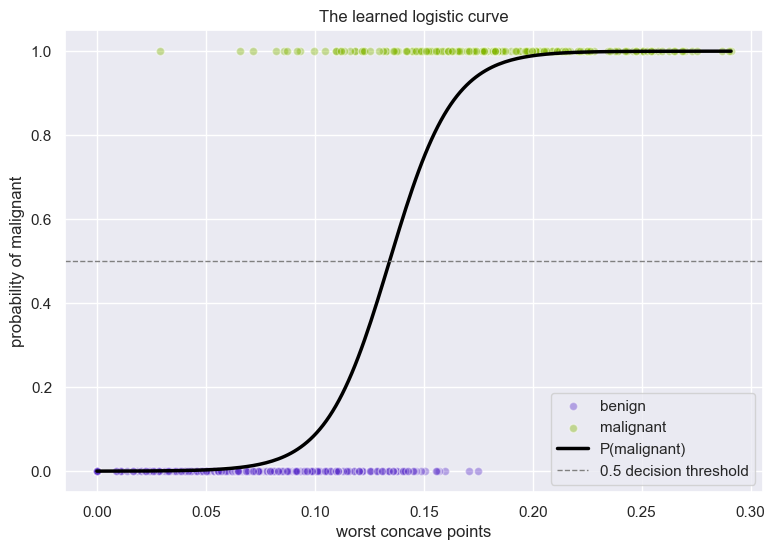

In [35]:
# A smooth range of real feature values to draw the curve over.
domain = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
domain_s = (domain - mean) / standard_deviation
curve = model.predict(domain_s)

plt.figure(figsize=(9, 6))
plt.scatter(X[y == 0], np.zeros((y == 0).sum()), color="#5d32ca", alpha=0.4, edgecolors="white", s=35, label="benign")
plt.scatter(X[y == 1], np.ones((y == 1).sum()),  color="#82b600", alpha=0.4, edgecolors="white", s=35, label="malignant")
plt.plot(domain, curve, color="black", lw=2.5, label="P(malignant)")
plt.axhline(0.5, color="gray", linestyle="dashed", lw=1, label="0.5 decision threshold")
plt.xlabel("worst concave points")
plt.ylabel("probability of malignant")
plt.title("The learned logistic curve")
plt.legend()
plt.show()

## Evaluating

To turn probabilities into a yes/no diagnosis, we threshold at **0.5**: above means predict malignant, below means benign. We check the accuracy on the held-out test set, then look at the **confusion matrix**, which breaks the predictions into correct and incorrect for each class, so we can see *what kind* of mistakes the model makes (not just how many).

Test accuracy: 88.6%


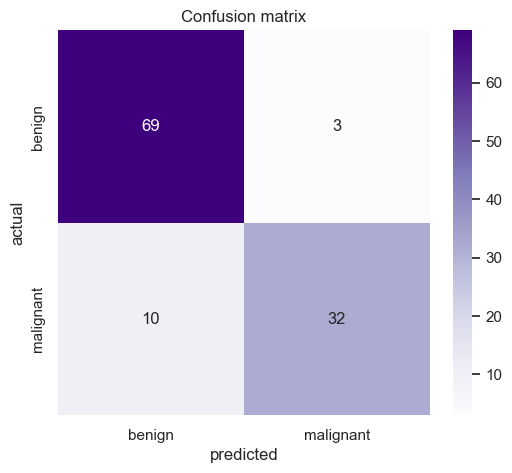

In [17]:
# Threshold the predicted probabilities into 0/1 class labels.
y_pred = (model.predict(X_test_s) >= 0.5).astype(int)
accuracy = (y_pred == y_test).mean()
print(f"Test accuracy: {accuracy:.1%}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["benign", "malignant"], yticklabels=["benign", "malignant"])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion matrix")
plt.show()

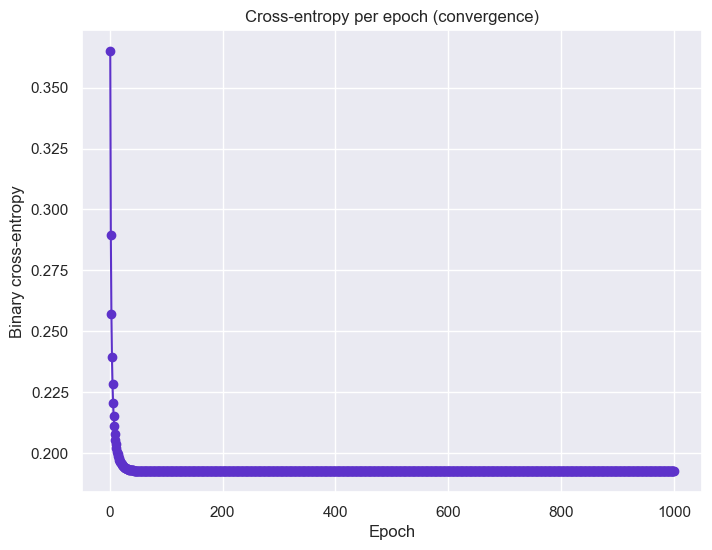

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(model.costs_) + 1), model.costs_, marker="o", color="#5d32ca")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Cross-entropy per epoch (convergence)")
plt.show()

## Conclusion

With a single feature, worst concave points, logistic regression reaches **88.6% test accuracy** on the breast cancer dataset. That number comes from swapping the perceptron's hard sign for a sigmoid: the model now outputs a probability instead of a forced guess, and the cross-entropy cost penalizes overconfident mistakes instead of just counting them. The confusion matrix shows that the remaining errors cluster in the overlap zone where benign and malignant tumors share similar concavity values, exactly the region where any single-feature model should be uncertain.

**Why this matters over the perceptron:** the perceptron could never converge on this data because the classes aren't linearly separable in one dimension. Logistic regression doesn't need perfect separation, it slides a smooth S-curve through the overlap and reports its confidence. A doctor receiving "78% likely malignant" can order a follow-up biopsy; a flat "malignant" gives no estimate of how borderline the case is. That probabilistic output is the core practical advantage.

**Limitations with one feature:** 88.6% means roughly 1 in 9 diagnoses is wrong, which is not clinical-grade. The model has only one number to work with, so two tumors with the same concavity but very different sizes get the same prediction. The next section adds a second feature to address exactly this.

## Try It Yourself

Change `worst_concave_points` to any value and run the cell to see the model's prediction.

In [55]:
worst_concave_points = 0.15  # change this value and re-run

x_new = np.array([[worst_concave_points]])
x_new_s = (x_new - mean) / standard_deviation
probability = model.predict(x_new_s)[0]
label = "malignant" if probability >= 0.5 else "benign"

print(f"Worst concave points: {worst_concave_points}")
print(f"Predicted probability of malignant: {probability:.1%}")
print(f"Predicted class: {label}")

Worst concave points: 0.15
Predicted probability of malignant: 74.6%
Predicted class: malignant


## Two Features

So far the model used a single feature, *worst concave points*, to predict malignancy. Adding a second feature, **worst radius** (how large the nucleus is), gives the model more information to work with. A malignant tumor tends to be both irregularly shaped *and* larger, so capturing both dimensions independently makes the boundary sharper.

The model itself is completely unchanged. The `net_input` already computes $\mathbf{w} \cdot \mathbf{x} + b$, which is just a dot product, it works for one feature or many. The only difference is that `X` now has two columns instead of one, so the model learns two weights (one per feature) instead of one. Everything else, the sigmoid, the cross-entropy, the update rule, the training loop, stays identical. Starting with one variable makes the curve intuitive to visualize, but seeing how much more powerful multiple variables is also very important.

In [45]:
X2 = df[["worst concave points", "worst radius"]].values

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=1)

# standardize using training set statistics only
mean2, std2 = X2_train.mean(axis=0), X2_train.std(axis=0)
X2_train_s = (X2_train - mean2) / std2
X2_test_s  = (X2_test  - mean2) / std2

model2 = LogisticRegression(eta=0.01, epochs=1000)
model2.train(X2_train_s, y2_train)

y2_pred = (model2.predict(X2_test_s) >= 0.5).astype(int)

print(f"Learned weights: concave points = {model2.weights_[0]:.2f},  radius = {model2.weights_[1]:.2f}")
print(f"Learned bias:    {model2.bias_:.2f}")
print(f"Final cross-entropy: {model2.costs_[-1]:.3f}")
print()
print(f"One feature accuracy:  {((model.predict(X_test_s) >= 0.5).astype(int) == y_test).mean():.1%}")
print(f"Two feature accuracy:  {(y2_pred == y2_test).mean():.1%}")

Learned weights: concave points = 3.70,  radius = 5.74
Learned bias:    -1.15
Final cross-entropy: 0.105

One feature accuracy:  88.6%
Two feature accuracy:  94.7%


### The Learned Probability Surface

With two features the model outputs a **surface** over the 2D feature space. The x and y axes are the two features, and the z axis is the predicted probability of malignant, you can literally see the sigmoid rising from 0 to 1 as both features increase. The gray plane at z = 0.5 marks the decision boundary: where the surface crosses it is where the model switches from predicting benign to malignant.

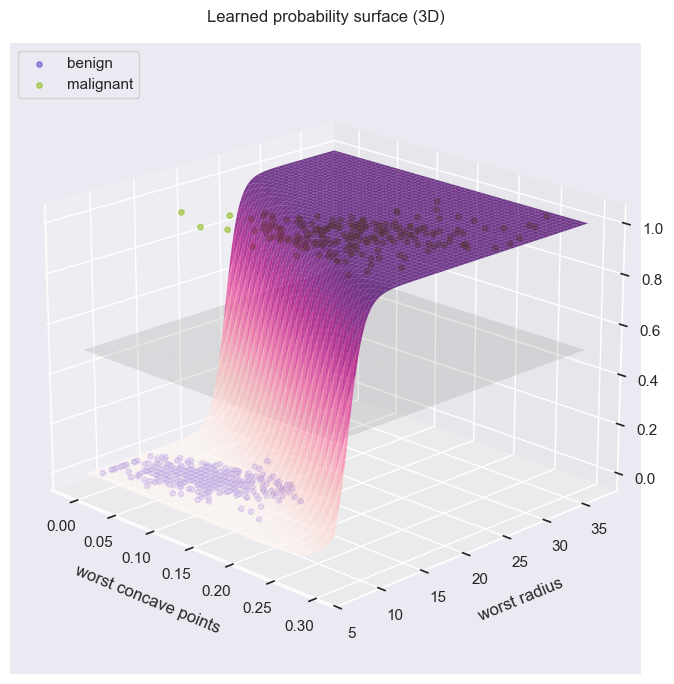

In [50]:
from mpl_toolkits.mplot3d import Axes3D

x_min, x_max = X2[:, 0].min() - 0.01, X2[:, 0].max() + 0.01
y_min, y_max = X2[:, 1].min() - 1,    X2[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid_s = (np.c_[xx.ravel(), yy.ravel()] - mean2) / std2
probs  = model2.predict(grid_s).reshape(xx.shape)

fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, probs, cmap="RdPu", alpha=0.75, edgecolor='none', zorder=1)

# decision boundary plane at 0.5
ax.plot_surface(xx, yy, np.full_like(probs, 0.5),
                color="gray", alpha=0.15, edgecolor='none', zorder=2)

# data points lifted to z=0 (benign) and z=1 (malignant) so they sit on the surface edges
ax.scatter(X2[y == 0, 0], X2[y == 0, 1], 0,
           color="#5d32ca", alpha=0.5, s=15, zorder=3, label="benign")
ax.scatter(X2[y == 1, 0], X2[y == 1, 1], 1,
           color="#82b600", alpha=0.5, s=15, zorder=3, label="malignant")

ax.set_xlabel("worst concave points", labelpad=10)
ax.set_ylabel("worst radius", labelpad=10)
ax.set_zlabel("P(malignant)", labelpad=8)
ax.set_title("Learned probability surface (3D)", pad=15)
ax.view_init(elev=20, azim=-45)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Convergence

The cross-entropy drops the same way as before, steeply at first, then leveling off. With two features feeding in more signal, the final cost lands lower than the single-feature model. Adding more features(variables) would push it lower still and improve accuracy further.

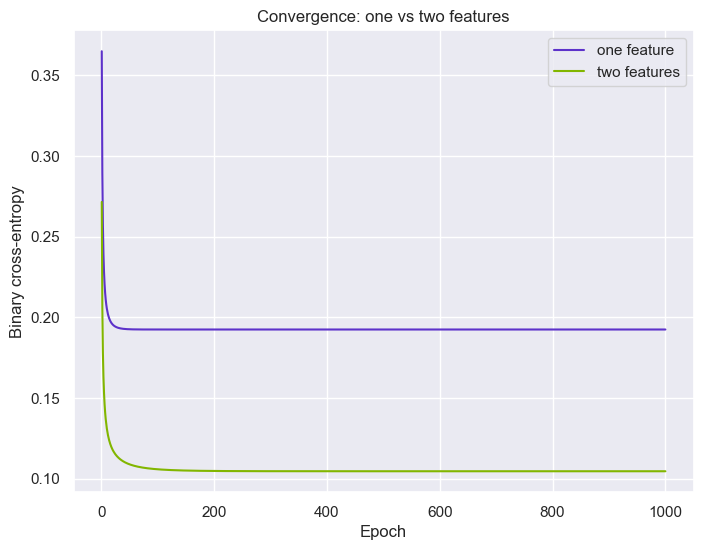

In [52]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(model.costs_) + 1),  model.costs_,  color="#5d32ca", label="one feature")
plt.plot(range(1, len(model2.costs_) + 1), model2.costs_, color="#82b600", label="two features")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Convergence: one vs two features")
plt.legend()
plt.show()

### Try It With Two Features

Change both values and run to see how the combined prediction differs from the single-feature version. Worst concave points range from about 0.0 to 0.3, and worst radius from about 7.0 to 36.0.

In [ ]:
worst_concave_points = 0.2
worst_radius         = 15.0

x_new2   = np.array([[worst_concave_points, worst_radius]])
x_new2_s = (x_new2 - mean2) / std2
prob2    = model2.predict(x_new2_s)[0]
x_new1   = np.array([[worst_concave_points]])
x_new1_s = (x_new1 - mean) / standard_deviation
prob1    = model.predict(x_new1_s)[0]

print(f"One feature  →  {prob1:.1%}  ({('malignant' if prob1 >= 0.5 else 'benign')})")
print(f"Two features →  {prob2:.1%}  ({('malignant' if prob2 >= 0.5 else 'benign')})")

One feature  →  98.9%  (malignant)
Two features →  86.7%  (malignant)


## Conclusion for Two Features

Adding worst radius alongside worst concave points jumped test accuracy from **88.6% to 94.7%** which is a 6-point gain from one extra column. The cross-entropy dropped from 0.192 to 0.105, meaning the model is not only more accurate but more *confident* on the cases it gets right. The learned weights (concave points = 3.70, radius = 5.74) show that the model leans harder on radius, which makes sense: tumor size is a strong independent signal that concavity alone can't capture. The 3D probability surface shows the sigmoid now rising along *two* axes, making a diagonal decision boundary that no single feature could draw.

**The key insight:** logistic regression's math didn't change at all, `net_input` was already computing a dot product, so going from one feature to two just meant learning two weights instead of one. The same sigmoid, same cross-entropy, same update rule. This scalability is a major practical strength because the model generalizes to any number of features without architectural changes.

**Tradeoff — more features isn't free:** each added feature needs enough training data to estimate its weight reliably. With 455 training samples and 2 features we're fine, but at 30 features we'd start wanting regularization (a penalty on large weights) to prevent overfitting. The model also still assumes a linear decision boundary in the feature space, if the true boundary curves or folds, stacking more features won't fix that. That's where nonlinear models like the multilayer perceptron and decision trees step in, which are covered later in this repository.